In [32]:
# Imports
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from config.settings import SILVER_DIR

import pandas as pd
import matplotlib.pyplot as plt
from data.timetable import (
    load_bronze,
    build_planned_timetable,
    add_segment_type,
    add_dynamics,
    add_time_in_seconds,
    add_period,
    assign_platforms,
    save_gold,
    load_gold,
    add_train_type,
    add_passing_time,
)

In [3]:
# Load bronze data
months = [
    '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512',
    '202601', '202602'
]
df = load_bronze(months)
print(f"Loaded: {len(df)} rows, {df['TRAIN_NO'].nunique()} trains")

Loaded: 2618072 rows, 1365 trains


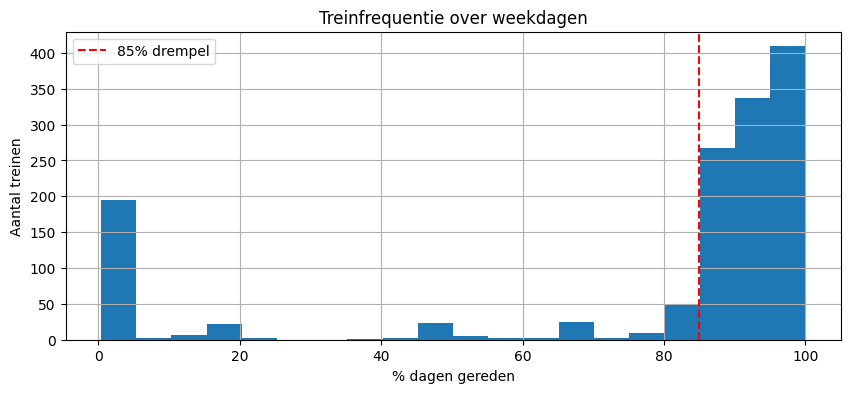

Treinen boven 85% drempel: 1028
Treinen onder 85% drempel: 337


In [3]:
train_counts = df.groupby('TRAIN_NO')['DATDEP'].nunique().reset_index()
train_counts.columns = ['TRAIN_NO', 'DAYS']
total_days = df['DATDEP'].nunique()
train_counts['PERCENTAGE'] = (train_counts['DAYS'] / total_days) * 100

train_counts['PERCENTAGE'].hist(bins=20, figsize=(10, 4))
plt.xlabel('% dagen gereden')
plt.ylabel('Aantal treinen')
plt.title('Treinfrequentie over weekdagen')
plt.axvline(x=85, color='red', linestyle='--', label='85% drempel')
plt.legend()
plt.show()

print(f"Treinen boven 85% drempel: {(train_counts['PERCENTAGE'] >= 85).sum()}")
print(f"Treinen onder 85% drempel: {(train_counts['PERCENTAGE'] < 85).sum()}")

## Checkpoint

`build_planned_timetable` itereert over alle 1367 treinen en vergelijkt timetable-varianten via `.equals()` — dit duurt enkele minuten. Het checkpoint slaat het ruwe resultaat op als parquet zodat je bij herwerking van latere stappen (segmenttype, platforms, ...) niet telkens opnieuw hoeft te builden.

**Cel 5 runnen** — enkel als de brondata of `build_planned_timetable` zelf gewijzigd is.  
**Cel 6 runnen** — altijd, bij elke herstart van de notebook.



In [4]:
# Bouw timetable en sla checkpoint op (enkel runnen als data verandert)
timetable = build_planned_timetable(df, min_frequency=0.85)
print(f"Trains after frequency filter: {timetable['TRAIN_NO'].nunique()}")

# Checkpoint opslaan — VOOR add_segment_type en assign_platforms
SILVER_DIR.mkdir(parents=True, exist_ok=True)
timetable.to_parquet(SILVER_DIR / 'timetable_raw.parquet', index=False)
print("Checkpoint opgeslagen.")

KeyboardInterrupt: 

In [4]:
# Laad checkpoint (snel, gebruik dit altijd)
timetable = pd.read_parquet(SILVER_DIR / 'timetable_raw.parquet')
print(f"Geladen: {timetable['TRAIN_NO'].nunique()} treinen")
print(f"Kolommen: {timetable.columns.tolist()}")

Geladen: 1028 treinen
Kolommen: ['SECTION', 'SOURCE', 'TARGET', 'PLANNED_ENTRY', 'PLANNED_EXIT', 'RELATION_DIRECTION', 'TRAIN_NO']


In [5]:
# Tijdsconventie na stap 3:
#   ENTRY_SECONDS = A_t,s = moment binnenkomst segment (vroeger)
#   EXIT_SECONDS  = D_t,s = moment verlaten segment    (later)
#   → altijd ENTRY_SECONDS < EXIT_SECONDS

timetable = add_segment_type(timetable)
timetable = add_train_type(timetable)
timetable = add_period(timetable)
timetable = add_time_in_seconds(timetable)
timetable = add_passing_time(timetable)   # sorteert intern op ENTRY_SECONDS
timetable = add_dynamics(timetable)       # sorteert intern op ENTRY_SECONDS
timetable, diagnostics = assign_platforms(timetable)

## Timetable overzicht

In [6]:
# Dynamiek verdeling
print(timetable['DYNAMICS'].value_counts())

DYNAMICS
0-0       4731
ACC-0     2907
0-BR      1505
ACC-BR     929
Name: count, dtype: int64


In [7]:
# Periode verdeling
print(timetable['PERIOD'].value_counts())

PERIOD
DAYTIME         4070
EVENING         2260
EVENING PEAK    1725
MORNING PEAK    1665
NIGHT            352
Name: count, dtype: int64


In [8]:
# Overzicht kolommen en datatypes
print(timetable.dtypes)
print(f"\nTotaal rijen: {len(timetable)}")
print(f"Totaal treinen: {timetable['TRAIN_NO'].nunique()}")
print(f"Totaal unieke secties: {timetable['SECTION'].nunique()}")

SECTION                          str
SOURCE                           str
TARGET                           str
PLANNED_ENTRY         datetime64[us]
PLANNED_EXIT          datetime64[us]
RELATION_DIRECTION               str
TRAIN_NO                       int64
TYPE                             str
TRAIN_TYPE                       str
PERIOD                           str
ENTRY_SECONDS                float64
EXIT_SECONDS                 float64
DYNAMICS                         str
SECTION_MACRO                    str
dtype: object

Totaal rijen: 10072
Totaal treinen: 1028
Totaal unieke secties: 122


## Validatie

In [9]:
# Valideer één trein visueel
train_no = timetable['TRAIN_NO'].iloc[0]
timetable[timetable['TRAIN_NO'] == train_no][
    ['TRAIN_NO', 'SOURCE', 'TARGET', 'SECTION',
     'TYPE', 'ENTRY_SECONDS', 'EXIT_SECONDS', 'PERIOD', 'DYNAMICS']
]

,TRAIN_NO,SOURCE,TARGET,SECTION,TYPE,ENTRY_SECONDS,EXIT_SECONDS,PERIOD,DYNAMICS
0,10,SCHAARBEEK,BRUSSEL-NOORD,36N:SCHAARBEEK-BRUSSEL-NOORD,SOURCE,60300.0,60480.0,EVENING,ACC-BR
1,10,BRUSSEL-NOORD,BRUSSEL-NOORD,BRUSSEL-NOORD -- platform 3,WITHIN-STATION-DWELL,60480.0,60600.0,EVENING,0-0
2,10,BRUSSEL-NOORD,BRUSSEL-CONGRES,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,BETWEEN-STATION,60600.0,60720.0,EVENING,ACC-0
3,10,BRUSSEL-CONGRES,BRUSSEL-CONGRES,BRUSSEL-CONGRES -- platform 1,WITHIN-STATION-PASSING,60720.0,60721.0,EVENING,0-0
4,10,BRUSSEL-CONGRES,BRUSSEL-CENTRAAL,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,BETWEEN-STATION,60721.0,60780.0,EVENING,0-0
5,10,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL -- platform 4,WITHIN-STATION-PASSING,60780.0,60781.0,EVENING,0-0
6,10,BRUSSEL-CENTRAAL,BRUSSEL-KAPELLEKERK,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,BETWEEN-STATION,60781.0,60900.0,EVENING,0-0
7,10,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK -- platform 4,WITHIN-STATION-PASSING,60900.0,60901.0,EVENING,0-0
8,10,BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,BETWEEN-STATION,60901.0,61020.0,EVENING,0-0


In [10]:
# Valideer segmenttypes
print(timetable['TYPE'].value_counts())

TYPE
BETWEEN-STATION           4522
WITHIN-STATION-DWELL      2434
WITHIN-STATION-PASSING    2088
SOURCE                    1028
Name: count, dtype: int64


In [11]:
# Valideer dat ENTRY_SECONDS monotoon stijgt per trein
niet_monotoon = (
    timetable
    .sort_values(['TRAIN_NO', 'ENTRY_SECONDS'])
    .groupby('TRAIN_NO')['ENTRY_SECONDS']
    .apply(lambda x: (x.diff().dropna() < 0).any())
)
treinen_niet_monotoon = niet_monotoon[niet_monotoon].index.tolist()

print(f"Treinen met niet-monotone ENTRY_SECONDS: {len(treinen_niet_monotoon)}")
if treinen_niet_monotoon:
    for t in treinen_niet_monotoon[:5]:
        print(f"\nTrein {t}:")
        print(timetable[timetable['TRAIN_NO'] == t][
            ['SOURCE', 'TARGET', 'TYPE', 'ENTRY_SECONDS', 'EXIT_SECONDS']
        ].to_string())

Treinen met niet-monotone ENTRY_SECONDS: 0


In [12]:
# Valideer tijden
#
# Voor ALLE segmenttypes: EXIT_SECONDS moet groter zijn dan ENTRY_SECONDS
# (trein verlaat segment na binnenkomst)

negatief = timetable[timetable['EXIT_SECONDS'] <= timetable['ENTRY_SECONDS']]
print(f"Ongeldige segmenten (EXIT <= ENTRY): {len(negatief)}")

if len(negatief) > 0:
    print(negatief['TYPE'].value_counts())
    print(negatief[['TRAIN_NO', 'SOURCE', 'TARGET', 'TYPE',
                     'ENTRY_SECONDS', 'EXIT_SECONDS']].head(10))

Ongeldige segmenten (EXIT <= ENTRY): 0


In [13]:
# Valideer platformtoewijzing
dwell_segmenten = timetable[timetable['TYPE'] == 'WITHIN-STATION-PASSING']
n_met    = dwell_segmenten['SECTION'].str.contains(' -- ', na=False).sum()
n_zonder = len(dwell_segmenten) - n_met

print(f"Dwell met platformtoewijzing:    {n_met}")
print(f"Dwell zonder platformtoewijzing: {n_zonder}")

if n_zonder > 0:
    print("\nStations zonder platformtoewijzing:")
    print(dwell_segmenten[~dwell_segmenten['SECTION'].str.contains(' -- ', na=False)]['SOURCE'].value_counts())

Dwell met platformtoewijzing:    2088
Dwell zonder platformtoewijzing: 0


In [14]:
for train_no in [11, 13, 408]:
    print(f"\n{'='*70}")
    print(f"TREIN {train_no}")
    print(f"{'='*70}")
    subset = timetable[timetable['TRAIN_NO'] == train_no].sort_values('ENTRY_SECONDS')
    print(subset[['SOURCE', 'TARGET', 'SECTION', 'TYPE', 'ENTRY_SECONDS', 'EXIT_SECONDS']].to_string(index=False))


TREIN 11
             SOURCE              TARGET                                  SECTION                   TYPE  ENTRY_SECONDS  EXIT_SECONDS
       BRUSSEL-ZUID BRUSSEL-KAPELLEKERK     0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK                 SOURCE         6300.0        6420.0
BRUSSEL-KAPELLEKERK BRUSSEL-KAPELLEKERK        BRUSSEL-KAPELLEKERK -- platform 2 WITHIN-STATION-PASSING         6420.0        6421.0
BRUSSEL-KAPELLEKERK    BRUSSEL-CENTRAAL 0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL        BETWEEN-STATION         6421.0        6480.0
   BRUSSEL-CENTRAAL    BRUSSEL-CENTRAAL           BRUSSEL-CENTRAAL -- platform 3 WITHIN-STATION-PASSING         6480.0        6481.0
   BRUSSEL-CENTRAAL     BRUSSEL-CONGRES     0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES        BETWEEN-STATION         6481.0        6540.0
    BRUSSEL-CONGRES     BRUSSEL-CONGRES            BRUSSEL-CONGRES -- platform 1 WITHIN-STATION-PASSING         6540.0        6541.0
    BRUSSEL-CONGRES       BRUSSEL-NOORD        0-1:BRUSSEL-

In [15]:
dwell_segmenten = timetable[timetable['TYPE'] == 'WITHIN-STATION-DWELL']
n_met    = dwell_segmenten['SECTION'].str.contains(' -- ', na=False).sum()
n_zonder = len(dwell_segmenten) - n_met

print(f"Dwell met platformtoewijzing:    {n_met}")
print(f"Dwell zonder platformtoewijzing: {n_zonder}")

Dwell met platformtoewijzing:    2434
Dwell zonder platformtoewijzing: 0


In [16]:
# Conflictdetectie
#
# CONFLICT_ID identificeert de fysieke sectie waarop twee treinen kunnen conflicteren:
#   - stationsegmenten: SOURCE -- platform
#   - tussenliggende segmenten: SECTION (ongewijzigd)
#
# Overlap check: interval [ENTRY, EXIT) van trein i overlapt met interval [ENTRY, EXIT) van trein j
# wanneer max(entry_i, entry_j) < min(exit_i, exit_j).
# Volledige O(n²) check — correcte algemene implementatie.

def get_conflict_id(row):
    if row['TYPE'] in ['WITHIN-STATION-DWELL', 'WITHIN-STATION-PASSING']:
        platform = row['SECTION'].split(' -- ')[1] if ' -- ' in row['SECTION'] else 'onbekend'
        return f"{row['SOURCE']} -- {platform}"
    return row['SECTION']

timetable['CONFLICT_ID'] = timetable.apply(get_conflict_id, axis=1)

conflicten = []
station_types = {'WITHIN-STATION-DWELL', 'WITHIN-STATION-PASSING'}

for cid, groep in timetable.groupby('CONFLICT_ID'):
    if groep['TYPE'].iloc[0] not in station_types:
        continue
    rows = groep.reset_index(drop=True)
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            ti, tj = rows.iloc[i], rows.iloc[j]
            overlap = min(ti['EXIT_SECONDS'], tj['EXIT_SECONDS']) - max(ti['ENTRY_SECONDS'], tj['ENTRY_SECONDS'])
            if overlap > 0:
                conflicten.append({
                    'CONFLICT_ID': cid,
                    'TRAIN_I':     ti['TRAIN_NO'],
                    'TRAIN_J':     tj['TRAIN_NO'],
                    'EXIT_I':      ti['EXIT_SECONDS'],
                    'ENTRY_J':     tj['ENTRY_SECONDS'],
                    'OVERLAP_SEC': overlap,
                })

df_conflicten = pd.DataFrame(conflicten)
print(f"Conflicten in geplande timetable: {len(df_conflicten)}")

Conflicten in geplande timetable: 14


In [17]:
# Maximale gelijktijdige bezetting per station
stations = ['BRUSSEL-KAPELLEKERK', 'BRUSSEL-NOORD', 'ANDERLECHT', 'BRUSSEL-CONGRES']

for station in stations:
    dwells = timetable[
        (timetable['SOURCE'] == station) &
        (timetable['TYPE'] == 'WITHIN-STATION-DWELL')
    ]
    if dwells.empty:
        continue

    max_bezetting = max(
        ((dwells['ENTRY_SECONDS'] <= t) & (dwells['EXIT_SECONDS'] > t)).sum()
        for t in dwells['ENTRY_SECONDS']
    )
    n_platforms = dwells['SECTION'].str.split(' -- ').str[-1].nunique()
    voldoende   = '✓' if max_bezetting <= n_platforms else '✗'

    print(f"{voldoende} {station}: max {max_bezetting} treinen tegelijk, {n_platforms} platforms")

✓ BRUSSEL-KAPELLEKERK: max 1 treinen tegelijk, 3 platforms
✓ BRUSSEL-NOORD: max 5 treinen tegelijk, 10 platforms
✓ BRUSSEL-CONGRES: max 1 treinen tegelijk, 4 platforms


In [18]:
# Gedetailleerde conflictinspectie per sectie
for cid in sorted(df_conflicten['CONFLICT_ID'].unique()):
    subset = df_conflicten[df_conflicten['CONFLICT_ID'] == cid]
    print(f"\n{'='*60}")
    print(f"{cid} ({len(subset)} conflict{'en' if len(subset) > 1 else ''})")
    print(f"{'='*60}")
    for _, row in subset.iterrows():
        trein_i = timetable[(timetable['TRAIN_NO'] == row['TRAIN_I']) & (timetable['CONFLICT_ID'] == cid)].iloc[0]
        trein_j = timetable[(timetable['TRAIN_NO'] == row['TRAIN_J']) & (timetable['CONFLICT_ID'] == cid)].iloc[0]
        dwell_i = int(trein_i['EXIT_SECONDS'] - trein_i['ENTRY_SECONDS'])
        dwell_j = int(trein_j['EXIT_SECONDS'] - trein_j['ENTRY_SECONDS'])
        soort_i = 'passing' if trein_i['TYPE'] == 'WITHIN-STATION-PASSING' else 'dwell'
        soort_j = 'passing' if trein_j['TYPE'] == 'WITHIN-STATION-PASSING' else 'dwell'
        print(f"  Trein {row['TRAIN_I']:>6} ({soort_i:>7}, {dwell_i:>3}s): entry {int(trein_i['ENTRY_SECONDS']):>6}s  exit {int(row['EXIT_I']):>6}s")
        print(f"  Trein {row['TRAIN_J']:>6} ({soort_j:>7}, {dwell_j:>3}s): entry {int(row['ENTRY_J']):>6}s  exit {int(trein_j['EXIT_SECONDS']):>6}s")
        print(f"  Overlap: {int(row['OVERLAP_SEC'])}s")
        print()


BRUSSEL-NOORD -- platform 10 (1 conflict)
  Trein    411 (  dwell, 180s): entry  28740s  exit  28920s
  Trein   3661 (  dwell, 120s): entry  28800s  exit  28920s
  Overlap: 120s


BRUSSEL-NOORD -- platform 9 (1 conflict)
  Trein   1945 (  dwell, 120s): entry  69660s  exit  69780s
  Trein   2045 (  dwell, 240s): entry  69720s  exit  69960s
  Overlap: 60s


JETTE -- platform 1 (12 conflicten)
  Trein   2157 (  dwell, 120s): entry  12240s  exit  12360s
  Trein   2256 (  dwell,  60s): entry  12240s  exit  12300s
  Overlap: 60s

  Trein   2158 (  dwell, 120s): entry  15840s  exit  15960s
  Trein   2257 (  dwell,  60s): entry  15840s  exit  15900s
  Overlap: 60s

  Trein   2159 (  dwell, 120s): entry  19440s  exit  19560s
  Trein   2258 (  dwell,  60s): entry  19440s  exit  19500s
  Overlap: 60s

  Trein   2160 (  dwell, 120s): entry  23040s  exit  23160s
  Trein   2259 (  dwell,  60s): entry  23040s  exit  23100s
  Overlap: 60s

  Trein   2161 (  dwell, 120s): entry  26640s  exit  26760s
 

In [19]:
# Sla op als gold
save_gold(
    timetable.drop(columns=['CONFLICT_ID', 'ENTRY_SECONDS', 'EXIT_SECONDS'], errors='ignore'),
    source='passenger',
)

Opgeslagen (passenger): 1028 treinen, 10072 segmenten → /Users/ddw/Desktop/Rescheduling/data/gold/passenger


In [39]:
df = load_gold("combined", 257)

df_last = (
    df.groupby("TRAIN_NO")
      .tail(1)
)

df_last_dwell = df_last[
    df_last["TRAIN_TYPE"] == "L"
]
df_last_dwell.head()


,SECTION,SOURCE,TARGET,PLANNED_ENTRY,PLANNED_EXIT,TRAIN_NO,TYPE,TRAIN_TYPE,PERIOD,DYNAMICS,ENTRY_SECONDS,EXIT_SECONDS
1378,25:BRUSSEL-NOORD-SCHAARBEEK,BRUSSEL-NOORD,SCHAARBEEK,2025-01-01 06:16:00,2025-01-01 06:19:00,1755,BETWEEN-STATION,L,MORNING PEAK,ACC-0,22443,22623
1389,25:BRUSSEL-NOORD-SCHAARBEEK,BRUSSEL-NOORD,SCHAARBEEK,2025-01-01 07:16:00,2025-01-01 07:19:00,1756,BETWEEN-STATION,L,MORNING PEAK,ACC-0,26043,26223
1400,25:BRUSSEL-NOORD-SCHAARBEEK,BRUSSEL-NOORD,SCHAARBEEK,2025-01-01 08:16:00,2025-01-01 08:19:00,1757,BETWEEN-STATION,L,MORNING PEAK,ACC-0,29643,29823
1411,25:BRUSSEL-NOORD-SCHAARBEEK,BRUSSEL-NOORD,SCHAARBEEK,2025-01-01 09:17:00,2025-01-01 09:20:00,1758,BETWEEN-STATION,L,DAYTIME,ACC-0,33303,33483
1422,25:BRUSSEL-NOORD-SCHAARBEEK,BRUSSEL-NOORD,SCHAARBEEK,2025-01-01 11:16:00,2025-01-01 11:19:00,1760,BETWEEN-STATION,L,DAYTIME,ACC-0,40443,40623


In [23]:
df.head(5)

,TRAIN_NO,SOURCE,TARGET,SECTION,PLANNED_ENTRY,PLANNED_EXIT,RELATION_DIRECTION,TYPE,DYNAMICS,PERIOD
0,900000,BRUSSEL-ZUID,BRUSSEL-WEST,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,2025-01-01 00:23:57.671310231,2025-01-01 00:30:27.671310231,T2b,BETWEEN-STATION,0-0,NIGHT
1,900000,BRUSSEL-WEST,BRUSSEL-WEST,BRUSSEL-WEST,2025-01-01 00:30:27.671310231,2025-01-01 00:30:28.671310231,T2b,WITHIN-STATION-PASSING,0-0,NIGHT
2,900000,BRUSSEL-WEST,SIMONIS,28(1):BRUSSEL-WEST-SIMONIS,2025-01-01 00:30:28.671310231,2025-01-01 00:31:59.671310231,T2b,BETWEEN-STATION,0-0,NIGHT
3,900000,SIMONIS,SIMONIS,SIMONIS,2025-01-01 00:31:59.671310231,2025-01-01 00:32:00.671310231,T2b,WITHIN-STATION-PASSING,0-0,NIGHT
4,900000,SIMONIS,THURN EN TAXIS,28(1):SIMONIS-THURN EN TAXIS,2025-01-01 00:32:00.671310231,2025-01-01 00:33:31.671310231,T2b,BETWEEN-STATION,0-0,NIGHT


In [26]:

between_sections  = df[df['TYPE'] == 'BETWEEN-STATION']['SECTION'].unique()
print(between_sections)


<ArrowStringArray>
[       '0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES',
     '0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL',
 '0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK',
     '0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID',
 '0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL',
     '0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES',
        '0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD',
             '36N:BRUSSEL-NOORD-SCHAARBEEK',
              '50:BRUSSEL-NOORD-SCHAARBEEK',
 '0-3:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL',
     '0-3:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES',
        '0-3:BRUSSEL-CONGRES-BRUSSEL-NOORD',
              '36:BRUSSEL-NOORD-SCHAARBEEK',
     '0-3:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK',
           '161-2:BRUSSEL-NOORD-SCHAARBEEK',
        '0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES',
     '0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL',
 '0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK',
     '0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID',
              '50C:BRUSSEL-ZUID-ANDERLECHT',
              '50A:BRUSSEL-ZUID-ANDERLECHT',
     '0-1:BRUSSEL-ZUID-BRUSSEL-KAPEL